<a href="https://colab.research.google.com/github/akshaybhatt97/365-DAYS-AI-ML-WITH-AKSHAY/blob/main/day_050_lightgbm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 50/365 — LightGBM
## How can Gradient Boosting become faster and more efficient on large tabular datasets?

Yesterday we learned **Early Stopping** with XGBoost.

Today we move to another major gradient-boosted tree library:

**LightGBM — Light Gradient Boosting Machine**

Like XGBoost, it builds trees sequentially to reduce a loss function.

Its key ideas include:
- histogram-based split finding
- leaf-wise tree growth
- efficient training on large structured datasets


In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, log_loss

try:
    from lightgbm import LGBMClassifier, early_stopping, log_evaluation
except ImportError:
    raise ImportError("Install LightGBM once with: pip install lightgbm")


## 1. Load the real Breast Cancer Wisconsin dataset


In [2]:
data=load_breast_cancer(as_frame=True)
X=data.data
y=data.target

X_trainval,X_test,y_trainval,y_test=train_test_split(
    X,y,test_size=0.20,random_state=42,stratify=y
)

X_train,X_val,y_train,y_val=train_test_split(
    X_trainval,y_trainval,test_size=0.25,random_state=42,stratify=y_trainval
)

print("Train:",X_train.shape)
print("Validation:",X_val.shape)
print("Test:",X_test.shape)


Train: (341, 30)
Validation: (114, 30)
Test: (114, 30)


## 2. Baseline: scikit-learn Gradient Boosting


In [3]:
start=time.perf_counter()

gb=GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb.fit(X_train,y_train)

gb_time=time.perf_counter()-start
gb_pred=gb.predict(X_test)
gb_prob=gb.predict_proba(X_test)

gb_acc=accuracy_score(y_test,gb_pred)
gb_loss=log_loss(y_test,gb_prob)

print("Gradient Boosting Accuracy:",round(gb_acc,3))
print("Gradient Boosting Log Loss:",round(gb_loss,3))
print("Training time:",round(gb_time,4),"seconds")


Gradient Boosting Accuracy: 0.93
Gradient Boosting Log Loss: 0.19
Training time: 4.1691 seconds


## 3. Train LightGBM

We also reuse **early stopping** from Day 49.


In [4]:
start=time.perf_counter()

lgbm=LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=15,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    verbosity=-1
)

lgbm.fit(
    X_train,
    y_train,
    eval_set=[(X_val,y_val)],
    eval_metric="logloss",
    callbacks=[
        early_stopping(stopping_rounds=30,verbose=False),
        log_evaluation(period=0)
    ]
)

lgbm_time=time.perf_counter()-start
lgbm_pred=lgbm.predict(X_test)
lgbm_prob=lgbm.predict_proba(X_test)

lgbm_acc=accuracy_score(y_test,lgbm_pred)
lgbm_loss=log_loss(y_test,lgbm_prob)

print("Best iteration:",lgbm.best_iteration_)
print("LightGBM Accuracy:",round(lgbm_acc,3))
print("LightGBM Log Loss:",round(lgbm_loss,3))
print("Training time:",round(lgbm_time,4),"seconds")


Best iteration: 191
LightGBM Accuracy: 0.956
LightGBM Log Loss: 0.119
Training time: 0.3667 seconds


## 4. Compare the models

This small dataset is **not** a serious speed benchmark.

The point is to understand how the workflow differs.


,Model,Test Accuracy,Test Log Loss,Training Time (s)
0,Gradient Boosting,0.9298,0.1899,4.1691
1,LightGBM,0.9561,0.1190,0.3667


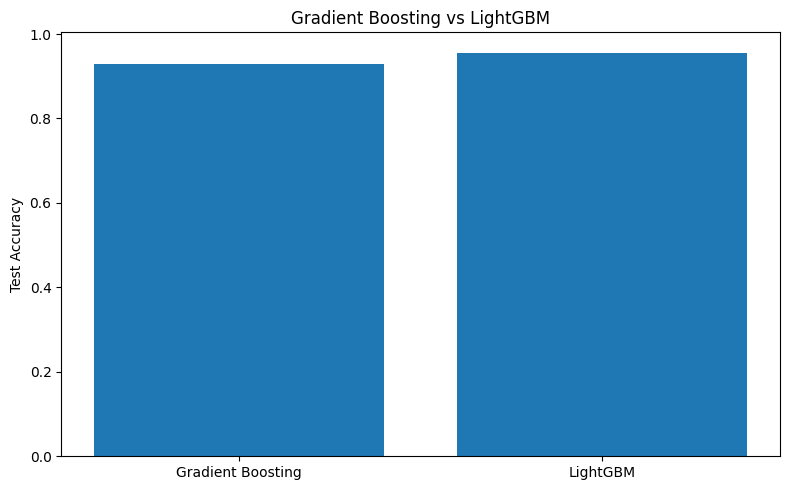

In [5]:
comparison=pd.DataFrame({
    "Model":["Gradient Boosting","LightGBM"],
    "Test Accuracy":[gb_acc,lgbm_acc],
    "Test Log Loss":[gb_loss,lgbm_loss],
    "Training Time (s)":[gb_time,lgbm_time]
})

display(comparison.round(4))

plt.figure(figsize=(8,5))
plt.bar(comparison["Model"],comparison["Test Accuracy"])
plt.ylabel("Test Accuracy")
plt.title("Gradient Boosting vs LightGBM")
plt.tight_layout()
plt.show()


## 5. Histogram-based learning

A normal tree may evaluate many possible numerical thresholds.

LightGBM groups continuous values into **bins**.

Conceptually:

`many raw feature values → fewer histogram bins → faster split search`

This can make training significantly more efficient on large datasets.


## 6. Leaf-wise tree growth

Many tree implementations grow approximately level by level.

LightGBM usually grows **leaf-wise**.

It expands the leaf whose next split can reduce the loss the most.

That can improve loss quickly, but it can also create complex trees.

So parameters such as:

- `num_leaves`
- `max_depth`
- `min_child_samples`

still matter.


## Enterprise intuition

Imagine millions of rows containing:

- transaction history
- customer behaviour
- account activity
- engineered risk features
- hundreds of columns

At that scale, model training speed and memory efficiency matter alongside predictive accuracy.

LightGBM is commonly used for structured/tabular tasks such as:

- fraud detection
- credit-risk scoring
- customer churn
- demand forecasting
- ranking
- claim-risk prediction

The important question is not simply:

**Which model gets the highest accuracy?**

It is also:

**Which model can we train, validate and iterate on efficiently?**


## XGBoost vs LightGBM

Both belong to the Gradient Boosting family.

### XGBoost
- regularized gradient boosting
- efficient tree construction
- row and column subsampling

### LightGBM
- gradient boosting
- histogram-based split finding
- leaf-wise growth
- designed for efficient large-scale tabular training

Neither is automatically better for every dataset.


## What does this teach?

- LightGBM is a Gradient Boosting system.
- Histogram bins reduce the split-search space.
- Leaf-wise growth expands the most promising leaf first.
- That efficiency is useful on large tabular datasets.
- Early stopping remains valuable.
- Accuracy alone is not the only production consideration.
- Small datasets should not be used to make broad speed claims.

> **In enterprise ML, a model must not only predict well — it must also be practical to train, validate and operate.**


## References

- https://lightgbm.readthedocs.io/en/stable/
- https://lightgbm.readthedocs.io/en/stable/Parameters.html
- https://proceedings.neurips.cc/paper/6907-lightgbm-a-highly-efficient-gradient-boosting-decision-tree
- https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html
